# 🔬 Phase 2: Multi-Omics Feature Extraction, Regulatory Signatures & Integrated Feature Store
## Genomically Stable (GS) vs. Chromosomal Instability (CIN) Gastric Cancer

---

### 📌 Overview & Scientific Motivation
Gastric cancer molecular subtypes display distinct multi-omics alteration landscapes:
1. **Transcriptomics & Differential Expression (DGE)**: Identifies key gene expression alterations distinguishing diffuse cell-adhesion driven **GS** tumors from aneuploid, cell-cycle driven **CIN** tumors.
2. **Transcription Factor (TF) Regulatory Inference (`decoupleR` + DoRothEA)**: Infers upstream TF regulatory activity scores from transcriptomics, capturing functional master regulators (*E2F1*, *MYC*, *TP53*, *STAT3*, *SNAI1*, *ZEB1*).
3. **Copy Number Alterations (CNA) & Genomic Instability**: Profile focal amplifications (*ERBB2*, *EGFR*, *MET*, *CCNE1*) and quantify overall Chromosomal Instability burden.
4. **Somatic Driver Mutations**: Map mutations in *TP53*, *CDH1*, *RHOA*, *ARID1A*, *PIK3CA*, and *KRAS*.
5. **Integrated Tabular Feature Store**: Concatenate aligned multi-omics features into `results/multiomics_feature_matrix.csv` for Phase 3 predictive machine learning modeling.

### 1. Environment Setup & Library Imports

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
import decoupler as dc

# Configure seaborn / matplotlib style for modern publication-ready figures
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

print("✅ Modular libraries and DecoupleR (v" + dc.__version__ + ") imported successfully.")

/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Modular libraries and DecoupleR (v2.1.4) imported successfully.


--- 
### 2. Clinical Cohort Ingestion & Sample Subtype Alignment

In [2]:
# Ingest Clinical Data
data_dir = "../stad_tcga_pub"
patient_path = os.path.join(data_dir, "data_clinical_patient.txt")
sample_path = os.path.join(data_dir, "data_clinical_sample.txt")

df_patient = pd.read_csv(patient_path, sep="\t", comment="#")
df_sample = pd.read_csv(sample_path, sep="\t", comment="#")

merged = pd.merge(df_sample, df_patient, on="PATIENT_ID", how="inner")
curated_clinical = merged[merged["MOLECULAR_SUBTYPE"].isin(["GS", "CIN"])].copy()

print(f"📊 Curated Clinical Cohort: {len(curated_clinical)} patients")
print(curated_clinical["MOLECULAR_SUBTYPE"].value_counts().to_string())

# Map sample IDs to subtype
sample2subtype = dict(zip(curated_clinical["SAMPLE_ID"], curated_clinical["MOLECULAR_SUBTYPE"]))

📊 Curated Clinical Cohort: 205 patients
MOLECULAR_SUBTYPE
CIN    147
GS      58


--- 
### 3. Transcriptomics: Differential Gene Expression (DGE) Analysis

We perform differential expression analysis comparing **CIN** vs. **GS** using Welch's t-test and Benjamini-Hochberg FDR correction ($q$-value).
The relative expression difference is calculated as $\\Delta \\bar{Z} = \\bar{Z}_{\\text{CIN}} - \\bar{Z}_{\\text{GS}}$.

In [3]:
# Load mRNA Z-scores
mrna_path = os.path.join(data_dir, "data_mrna_seq_v2_rsem_zscores_ref_diploid_samples.txt")
df_mrna = pd.read_csv(mrna_path, sep="\t")

# Set Hugo_Symbol as index and drop Entrez ID
df_mrna_expr = df_mrna.drop_duplicates(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
if "Entrez_Gene_Id" in df_mrna_expr.columns:
    df_mrna_expr = df_mrna_expr.drop(columns=["Entrez_Gene_Id"])

# Identify overlapping sample columns
aligned_mrna_samples = [s for s in curated_clinical["SAMPLE_ID"] if s in df_mrna_expr.columns]
expr_matrix = df_mrna_expr[aligned_mrna_samples].dropna(thresh=int(len(aligned_mrna_samples)*0.7))

print(f"🧬 Analyzed Genes: {len(expr_matrix)}, Aligned Samples: {len(aligned_mrna_samples)}")

cin_samples = [s for s in aligned_mrna_samples if sample2subtype[s] == "CIN"]
gs_samples = [s for s in aligned_mrna_samples if sample2subtype[s] == "GS"]

print(f"   - CIN Samples: {len(cin_samples)}, GS Samples: {len(gs_samples)}")

# Compute DGE statistics per gene
dge_rows = []
for gene, row in expr_matrix.iterrows():
    cin_vals = row[cin_samples].values
    gs_vals = row[gs_samples].values

    mean_cin = np.mean(cin_vals)
    mean_gs = np.mean(gs_vals)
    delta_z = mean_cin - mean_gs

    # Welch's t-test
    stat, p_val = stats.ttest_ind(cin_vals, gs_vals, equal_var=False, nan_policy="omit")
    dge_rows.append({
        "Gene": gene,
        "Mean_CIN": mean_cin,
        "Mean_GS": mean_gs,
        "Delta_Z": delta_z,
        "p_value": p_val
    })

df_dge = pd.DataFrame(dge_rows).dropna(subset=["p_value"])

# Benjamini-Hochberg FDR correction
_, q_vals, _, _ = multipletests(df_dge["p_value"], method="fdr_bh")
df_dge["q_value"] = q_vals
df_dge["neg_log10_q"] = -np.log10(df_dge["q_value"].clip(lower=1e-15))

df_dge = df_dge.sort_values("q_value")

# Export DGE summary
os.makedirs("../results", exist_ok=True)
df_dge.to_csv("../results/dge_summary_gs_vs_cin.csv", index=False)
print("💾 Saved DGE results to results/dge_summary_gs_vs_cin.csv")

print("\n🔥 Top 10 Upregulated Genes in CIN:")
display(df_dge.head(10)[["Gene", "Mean_CIN", "Mean_GS", "Delta_Z", "p_value", "q_value"]])

print("\n🔥 Top 10 Upregulated Genes in GS:")
display(df_dge.sort_values("Delta_Z").head(10)[["Gene", "Mean_CIN", "Mean_GS", "Delta_Z", "p_value", "q_value"]])

🧬 Analyzed Genes: 21336, Aligned Samples: 182
   - CIN Samples: 128, GS Samples: 54


/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/pyth

/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/pyth

/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


...

/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/home/parth/miniconda3/envs/gs_vs_cin/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


💾 Saved DGE results to results/dge_summary_gs_vs_cin.csv

🔥 Top 10 Upregulated Genes in CIN:


,Gene,Mean_CIN,Mean_GS,Delta_Z,p_value,q_value
13160,OR11H1,-0.133800,-0.133800,2.775558e-17,7.603066e-21,1.622114e-16
15333,RAE1,2.843149,-0.168585,3.011734e+00,1.173069e-19,1.251371e-15
1309,AURKA,1.671433,-0.558165,2.229598e+00,2.546262e-18,1.810817e-14
20521,YTHDF1,2.632191,-0.104261,2.736453e+00,6.532469e-18,3.484256e-14
19901,UCKL1,1.913312,-0.318952,2.232264e+00,1.488577e-17,5.561180e-14
19327,TPD52L2,1.783462,-0.241337,2.024800e+00,1.563960e-17,5.561180e-14
19371,TPX2,1.094266,-0.649935,1.744202e+00,1.963744e-17,5.985211e-14
4976,DSN1,1.733817,-0.461044,2.194862e+00,3.497752e-17,9.328066e-14
5067,E2F1,1.045699,-0.521643,1.567342e+00,7.804202e-17,1.850029e-13
3315,CERS2,1.331573,-0.580689,1.912262e+00,9.548464e-17,2.037165e-13



🔥 Top 10 Upregulated Genes in GS:


,Gene,Mean_CIN,Mean_GS,Delta_Z,p_value,q_value
6735,GCG,-0.069593,3.682915,-3.752508,2.840699e-01,4.026195e-01
13608,P2RY8,-0.340538,1.765724,-2.106262,1.075264e-01,1.901903e-01
10777,LRMP,-0.083288,1.562680,-1.645968,2.000972e-01,3.078363e-01
8001,HTR3A,0.008700,1.441954,-1.433254,3.116148e-01,4.311062e-01
14548,POU2AF1,-0.261473,1.079248,-1.340721,9.385792e-02,1.708391e-01
3014,CD27,-0.294798,1.001357,-1.296155,4.972546e-02,1.029593e-01
3971,CRLF2,-0.216593,1.074750,-1.291343,6.039341e-02,1.204988e-01
18088,STAB2,-0.140514,1.123398,-1.263912,1.106128e-01,1.943667e-01
12673,NLGN3,-0.270297,0.973535,-1.243832,2.144183e-07,4.524841e-06
14834,PRMT2,-0.647652,0.589054,-1.236705,5.239841e-11,6.424828e-09


--- 
### 4. DGE Volcano Plot Visualization

2026-09-16 20:03:55 | [INFO] maxp pruned


2026-09-16 20:03:55 | [INFO] cmap pruned


2026-09-16 20:03:55 | [INFO] kern dropped


2026-09-16 20:03:55 | [INFO] post pruned


2026-09-16 20:03:55 | [INFO] FFTM dropped


...

2026-09-16 20:03:56 | [INFO] GDEF pruned


2026-09-16 20:03:56 | [INFO] GPOS pruned


2026-09-16 20:03:56 | [INFO] GSUB pruned


2026-09-16 20:03:56 | [INFO] name pruned


💾 Saved Volcano Plot to figures/volcano_dge_gs_vs_cin.png


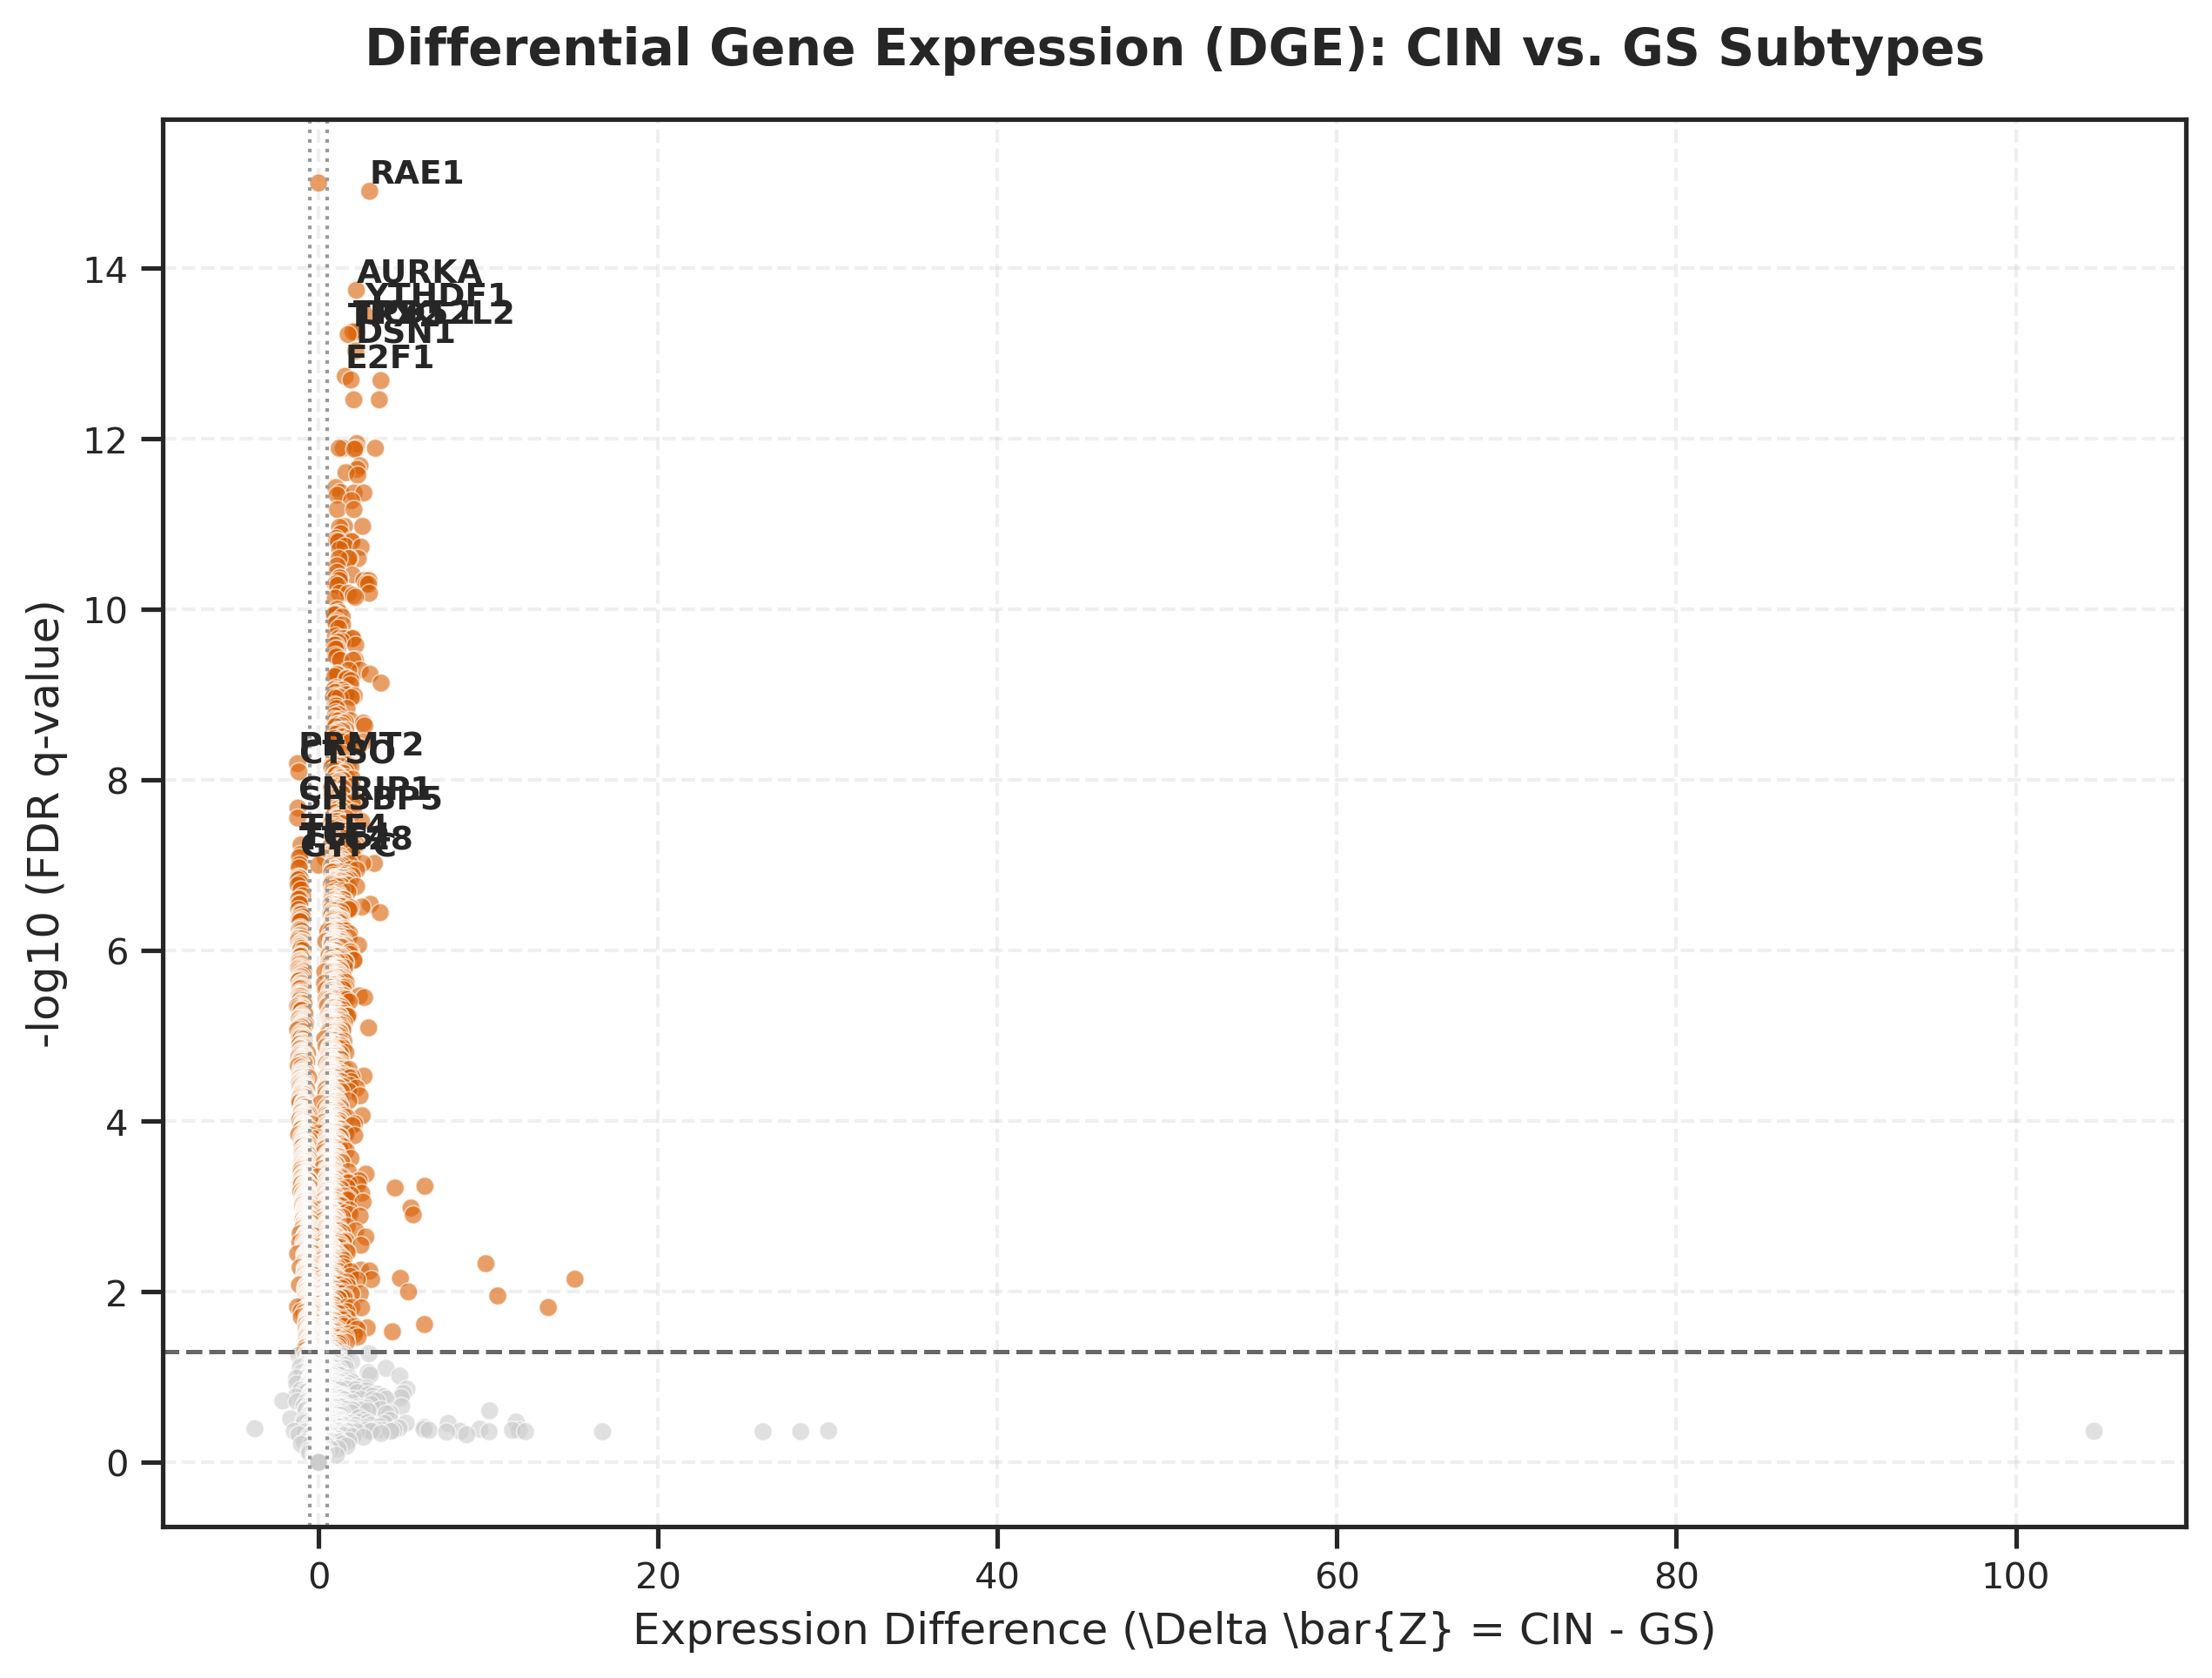

In [4]:
# Plot Volcano Plot
fig, ax = plt.subplots(figsize=(10, 7), dpi=300)

# Scatter plot
sns.scatterplot(
    data=df_dge,
    x="Delta_Z",
    y="neg_log10_q",
    hue=df_dge["q_value"] < 0.05,
    palette={True: "#d95f02", False: "#cccccc"},
    alpha=0.6,
    s=25,
    ax=ax,
    legend=False
)

# Threshold lines
ax.axhline(-np.log10(0.05), linestyle="--", color="#666666", linewidth=1.2, label="FDR q = 0.05")
ax.axvline(0.5, linestyle=":", color="#999999", linewidth=1)
ax.axvline(-0.5, linestyle=":", color="#999999", linewidth=1)

# Annotate key driver genes
top_genes_cin = df_dge[(df_dge["Delta_Z"] > 0.5) & (df_dge["q_value"] < 0.01)].head(8)["Gene"].values
top_genes_gs = df_dge[(df_dge["Delta_Z"] < -0.5) & (df_dge["q_value"] < 0.01)].head(8)["Gene"].values

for gene in list(top_genes_cin) + list(top_genes_gs):
    r = df_dge[df_dge["Gene"] == gene].iloc[0]
    ax.text(r["Delta_Z"], r["neg_log10_q"] + 0.1, gene, fontsize=9, fontweight="bold")

ax.set_title("Differential Gene Expression (DGE): CIN vs. GS Subtypes", pad=15, fontweight="bold")
ax.set_xlabel("Expression Difference (\\Delta \\bar{Z} = CIN - GS)")
ax.set_ylabel("-log10 (FDR q-value)")
ax.grid(True, linestyle="--", alpha=0.3)

os.makedirs("../figures", exist_ok=True)
fig.savefig("../figures/volcano_dge_gs_vs_cin.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/volcano_dge_gs_vs_cin.pdf", bbox_inches="tight")
print("💾 Saved Volcano Plot to figures/volcano_dge_gs_vs_cin.png")
plt.show()

--- 
### 5. Transcription Factor (TF) Activity Inference via `decoupleR` & DoRothEA

We apply **`decoupleR`** to infer sample-level upstream transcription factor regulatory activity scores using the human **DoRothEA** regulon database.
The Univariate Linear Model (**ULM**) method fits per-sample gene expression against TF target weight matrices.

In [5]:
# Fetch DoRothEA regulon network
dorothea_net = dc.op.dorothea(organism="human")

# Filter network for high-confidence regulons (Confidence A, B, C)
dorothea_net = dorothea_net[dorothea_net["confidence"].isin(["A", "B", "C"])].copy()

# Format expression matrix (samples as rows, genes as columns)
mat_expr = expr_matrix.T.copy()

# Run ULM algorithm in decoupleR
tf_act, tf_pval = dc.mt.ulm(mat_expr, dorothea_net, tmin=3)

print(f"⚡ Inferred TF Activity Scores Matrix: {tf_act.shape[0]} samples x {tf_act.shape[1]} TFs")

# Add subtype annotation to TF activity matrix
tf_act_df = tf_act.copy()
tf_act_df["MOLECULAR_SUBTYPE"] = [sample2subtype.get(s, np.nan) for s in tf_act_df.index]

# Export TF activity matrix
tf_act_df.to_csv("../results/tf_activity_matrix.csv")
print("💾 Saved TF activity matrix to results/tf_activity_matrix.csv")

# Compute differential TF activities between GS and CIN
diff_tf_rows = []
for tf in tf_act.columns:
    cin_acts = tf_act_df[tf_act_df["MOLECULAR_SUBTYPE"] == "CIN"][tf].dropna()
    gs_acts = tf_act_df[tf_act_df["MOLECULAR_SUBTYPE"] == "GS"][tf].dropna()

    mean_cin = np.mean(cin_acts)
    mean_gs = np.mean(gs_acts)
    diff_act = mean_cin - mean_gs

    stat, p_val = stats.mannwhitneyu(cin_acts, gs_acts, alternative="two-sided")
    diff_tf_rows.append({
        "TF": tf,
        "Mean_Act_CIN": mean_cin,
        "Mean_Act_GS": mean_gs,
        "Delta_Activity": diff_act,
        "p_value": p_val
    })

df_diff_tf = pd.DataFrame(diff_tf_rows).dropna(subset=["p_value"]).sort_values("p_value")
_, df_diff_tf["q_value"], _, _ = multipletests(df_diff_tf["p_value"], method="fdr_bh")

df_diff_tf.to_csv("../results/differential_tf_activity.csv", index=False)
print("💾 Saved Differential TF summary to results/differential_tf_activity.csv")

print("\n🔥 Top Differential Transcription Factors:")
display(df_diff_tf.head(12)[["TF", "Mean_Act_CIN", "Mean_Act_GS", "Delta_Activity", "p_value", "q_value"]])

⚡ Inferred TF Activity Scores Matrix: 182 samples x 333 TFs
💾 Saved TF activity matrix to results/tf_activity_matrix.csv


💾 Saved Differential TF summary to results/differential_tf_activity.csv

🔥 Top Differential Transcription Factors:


,TF,Mean_Act_CIN,Mean_Act_GS,Delta_Activity,p_value,q_value
43,E2F3,0.481391,-1.576011,2.057402,1.185495e-13,2.116355e-11
42,E2F2,0.182840,-2.268739,2.451578,1.271084e-13,2.116355e-11
93,GLI1,-0.263029,0.728673,-0.991702,2.163058e-13,2.400995e-11
44,E2F4,0.114571,-5.545337,5.659908,1.210001e-12,9.417870e-11
290,TFDP1,0.570239,-2.430586,3.000825,1.414095e-12,9.417870e-11
48,EBF1,-0.334548,2.768182,-3.102730,2.804642e-12,1.556576e-10
153,MEF2C,-0.527872,1.908446,-2.436318,9.246054e-12,4.398480e-10
189,NR2C2,1.285034,-1.373733,2.658767,1.866102e-11,7.767648e-10
295,TP53,-0.994191,1.897209,-2.891401,4.136894e-11,1.530651e-09
293,THAP11,0.761588,-1.128521,1.890109,6.256061e-11,2.083268e-09


--- 
### 6. Differential TF Activity Heatmap Visualization

2026-09-16 20:03:59 | [INFO] maxp pruned


2026-09-16 20:03:59 | [INFO] cmap pruned


2026-09-16 20:03:59 | [INFO] kern dropped


2026-09-16 20:03:59 | [INFO] post pruned


2026-09-16 20:03:59 | [INFO] FFTM dropped


...

2026-09-16 20:03:59 | [INFO] GDEF pruned


2026-09-16 20:03:59 | [INFO] GPOS pruned


2026-09-16 20:03:59 | [INFO] GSUB pruned


2026-09-16 20:03:59 | [INFO] name pruned


💾 Saved TF Activity Heatmap to figures/heatmap_tf_activity.png


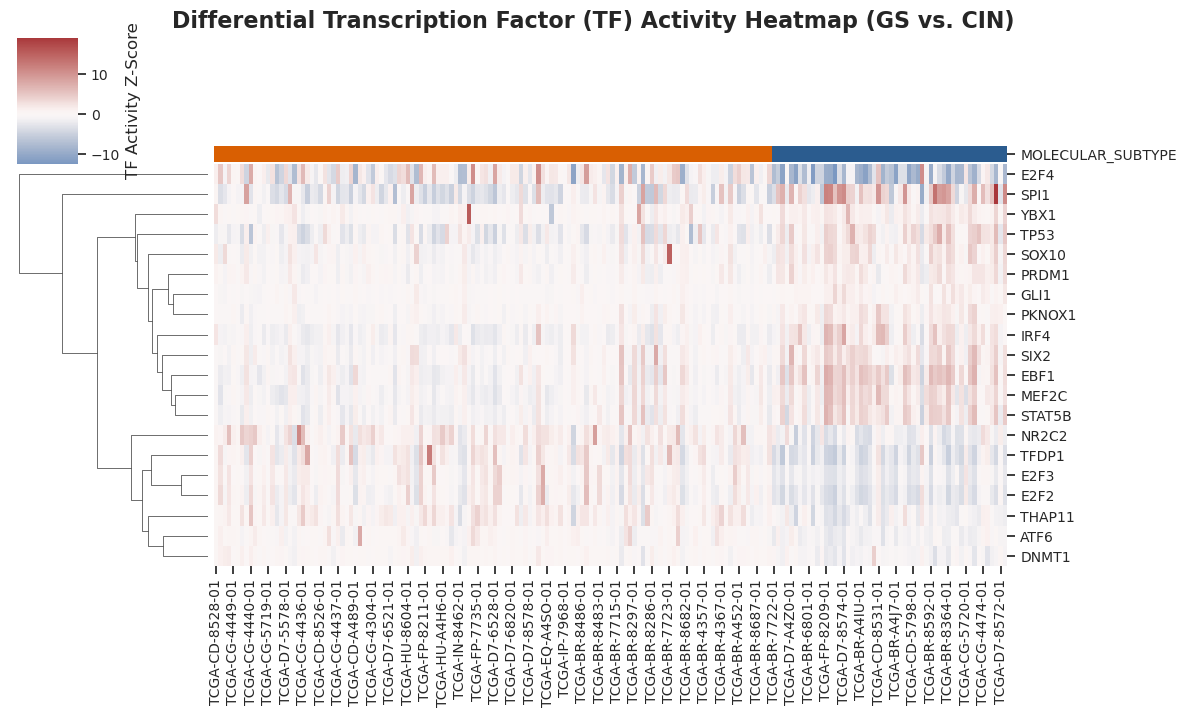

In [6]:
# Select top 20 differential TFs
top_tfs = df_diff_tf.head(20)["TF"].values

# Prepare heatmap matrix
heatmap_mat = tf_act[top_tfs].copy()

# Sort samples by subtype (GS first, then CIN)
sample_order = tf_act_df.sort_values("MOLECULAR_SUBTYPE").index
heatmap_mat = heatmap_mat.loc[sample_order]

# Subtype color bar
subtype_colors = tf_act_df.loc[sample_order, "MOLECULAR_SUBTYPE"].map({"GS": "#2b5c8f", "CIN": "#d95f02"})

# Clustered Heatmap
g = sns.clustermap(
    heatmap_mat.T,
    cmap="vlag",
    center=0,
    col_cluster=False,
    row_cluster=True,
    col_colors=subtype_colors,
    figsize=(12, 7),
    cbar_kws={"label": "TF Activity Z-Score"}
)

g.fig.suptitle("Differential Transcription Factor (TF) Activity Heatmap (GS vs. CIN)", y=1.02, fontweight="bold")
g.savefig("../figures/heatmap_tf_activity.png", bbox_inches="tight", dpi=300)
g.savefig("../figures/heatmap_tf_activity.pdf", bbox_inches="tight")
print("💾 Saved TF Activity Heatmap to figures/heatmap_tf_activity.png")
plt.show()

--- 
### 7. Copy Number Alterations (CNA) & Genomic Instability Profiling

Evaluating copy-number states (-2: deep deletion, -1: shallow deletion, 0: diploid, 1: gain, 2: high-level amplification) for key driver oncogenes and tumor suppressors (*ERBB2*, *EGFR*, *MET*, *CCNE1*, *TP53*, *CDH1*) and quantifying **Chromosomal Instability Burden**.

In [7]:
# Ingest CNA Data
cna_path = os.path.join(data_dir, "data_cna.txt")
df_cna = pd.read_csv(cna_path, sep="\t")

df_cna_genes = df_cna.drop_duplicates(subset=["Hugo_Symbol"]).set_index("Hugo_Symbol")
if "Entrez_Gene_Id" in df_cna_genes.columns:
    df_cna_genes = df_cna_genes.drop(columns=["Entrez_Gene_Id"])

aligned_cna_samples = [s for s in curated_clinical["SAMPLE_ID"] if s in df_cna_genes.columns]
cna_matrix = df_cna_genes[aligned_cna_samples]

cin_cna_samples = [s for s in aligned_cna_samples if sample2subtype[s] == "CIN"]
gs_cna_samples = [s for s in aligned_cna_samples if sample2subtype[s] == "GS"]

print(f"📊 CNA Genes: {len(cna_matrix)}, Aligned CNA Samples: {len(aligned_cna_samples)} (CIN: {len(cin_cna_samples)}, GS: {len(gs_cna_samples)})")

# Calculate Chromosomal Instability (CNA) Burden per sample (fraction of non-zero altered genes)
cna_burden = (cna_matrix != 0).sum(axis=0) / len(cna_matrix)
df_cna_summary = pd.DataFrame({
    "SAMPLE_ID": aligned_cna_samples,
    "CNA_Burden": cna_burden.values,
    "MOLECULAR_SUBTYPE": [sample2subtype[s] for s in aligned_cna_samples]
})

# Compare CNA Burden (GS vs CIN)
cin_burden = df_cna_summary[df_cna_summary["MOLECULAR_SUBTYPE"] == "CIN"]["CNA_Burden"]
gs_burden = df_cna_summary[df_cna_summary["MOLECULAR_SUBTYPE"] == "GS"]["CNA_Burden"]

stat, p_val_cna = stats.mannwhitneyu(cin_burden, gs_burden, alternative="two-sided")
print(f"🔥 Chromosomal Instability Burden Mann-Whitney U p-value: p = {p_val_cna:.4e}")
print(f"   - CIN Median Burden: {cin_burden.median():.3f} (IQR: {cin_burden.quantile(0.25):.3f}-{cin_burden.quantile(0.75):.3f})")
print(f"   - GS Median Burden:  {gs_burden.median():.3f} (IQR: {gs_burden.quantile(0.25):.3f}-{gs_burden.quantile(0.75):.3f})")

# Extract Key Driver Genes CNA states
driver_genes = ["ERBB2", "EGFR", "MET", "FGFR2", "CCNE1", "CCND1", "CDK6", "TP53", "CDH1", "ARHGAP26"]
existing_drivers = [g for g in driver_genes if g in cna_matrix.index]

df_driver_cna = cna_matrix.loc[existing_drivers].T
df_driver_cna["MOLECULAR_SUBTYPE"] = [sample2subtype[s] for s in df_driver_cna.index]
df_driver_cna.to_csv("../results/cna_driver_matrix.csv")
print("💾 Saved CNA driver matrix to results/cna_driver_matrix.csv")

📊 CNA Genes: 24164, Aligned CNA Samples: 204 (CIN: 147, GS: 57)
🔥 Chromosomal Instability Burden Mann-Whitney U p-value: p = 6.4176e-28
   - CIN Median Burden: 0.572 (IQR: 0.471-0.694)
   - GS Median Burden:  0.098 (IQR: 0.053-0.193)
💾 Saved CNA driver matrix to results/cna_driver_matrix.csv


--- 
### 8. CNA Instability Burden & Driver Gene Alteration Visualizations

/tmp/ipykernel_12018/2537580470.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
2026-09-16 20:04:00 | [INFO] maxp pruned


2026-09-16 20:04:00 | [INFO] cmap pruned


2026-09-16 20:04:00 | [INFO] kern dropped


2026-09-16 20:04:00 | [INFO] post pruned


2026-09-16 20:04:00 | [INFO] FFTM dropped


...

2026-09-16 20:04:00 | [INFO] GDEF pruned


2026-09-16 20:04:00 | [INFO] GPOS pruned


2026-09-16 20:04:00 | [INFO] GSUB pruned


2026-09-16 20:04:00 | [INFO] name pruned


💾 Saved CNA Burden Boxplot to figures/boxplot_cna_burden.png


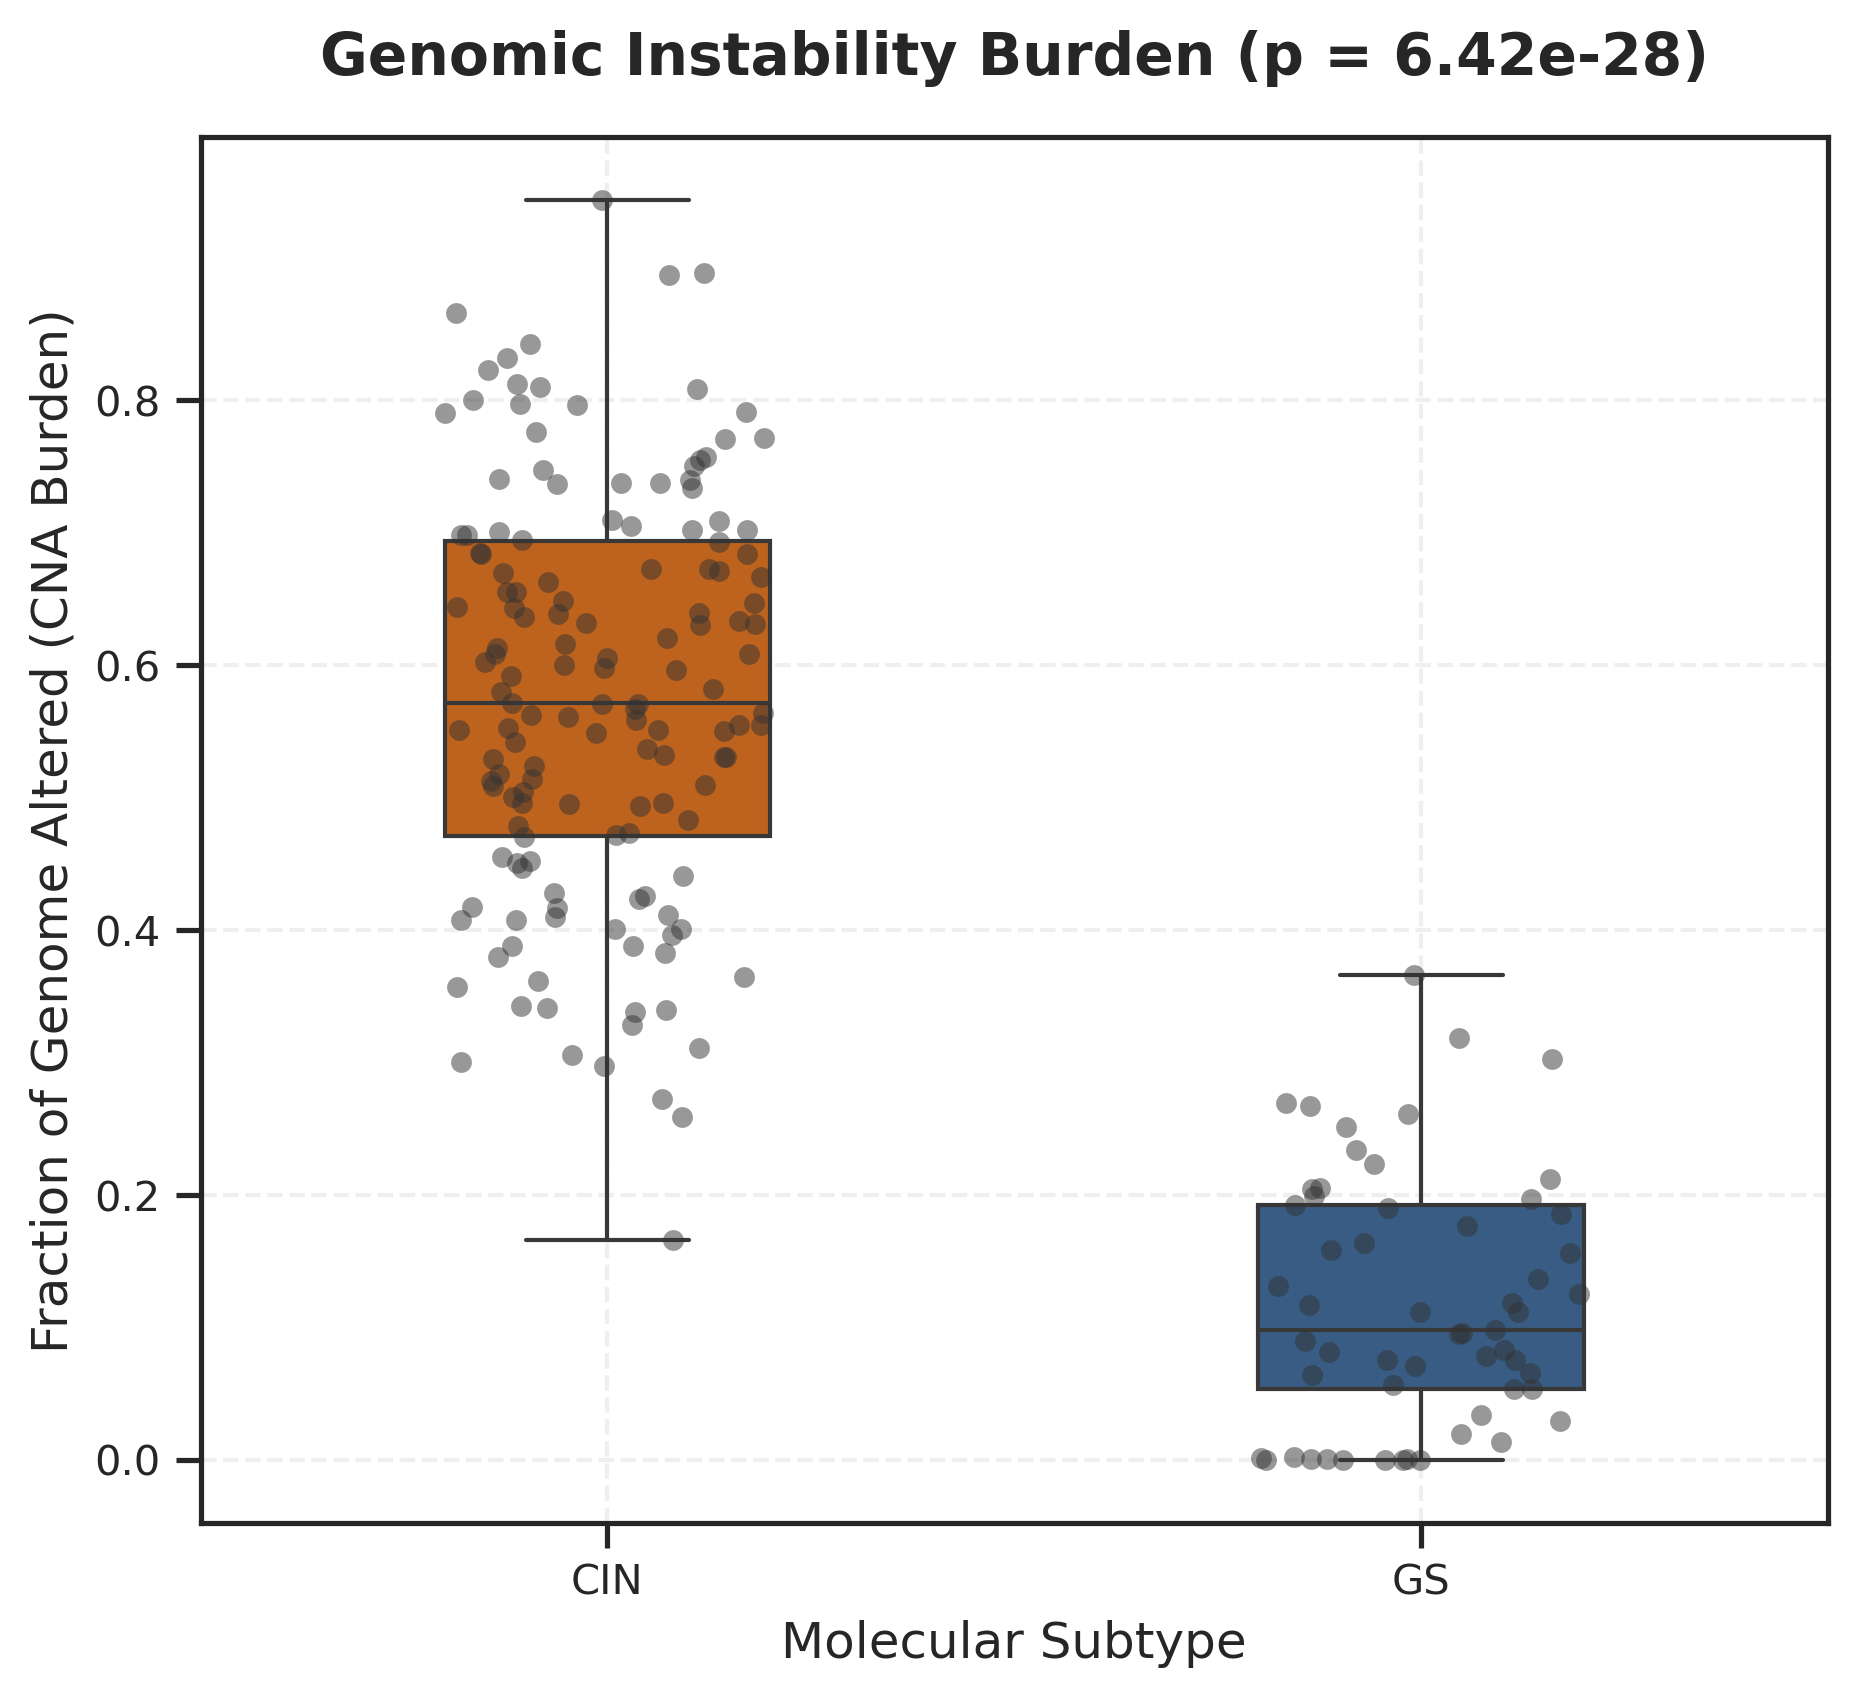

2026-09-16 20:04:00 | [INFO] maxp pruned


2026-09-16 20:04:00 | [INFO] cmap pruned


2026-09-16 20:04:00 | [INFO] kern dropped


2026-09-16 20:04:00 | [INFO] post pruned


2026-09-16 20:04:00 | [INFO] FFTM dropped


...

2026-09-16 20:04:01 | [INFO] GDEF pruned


2026-09-16 20:04:01 | [INFO] GPOS pruned


2026-09-16 20:04:01 | [INFO] GSUB pruned


2026-09-16 20:04:01 | [INFO] name pruned


💾 Saved Driver Alteration Barplot to figures/barplot_cna_drivers.png


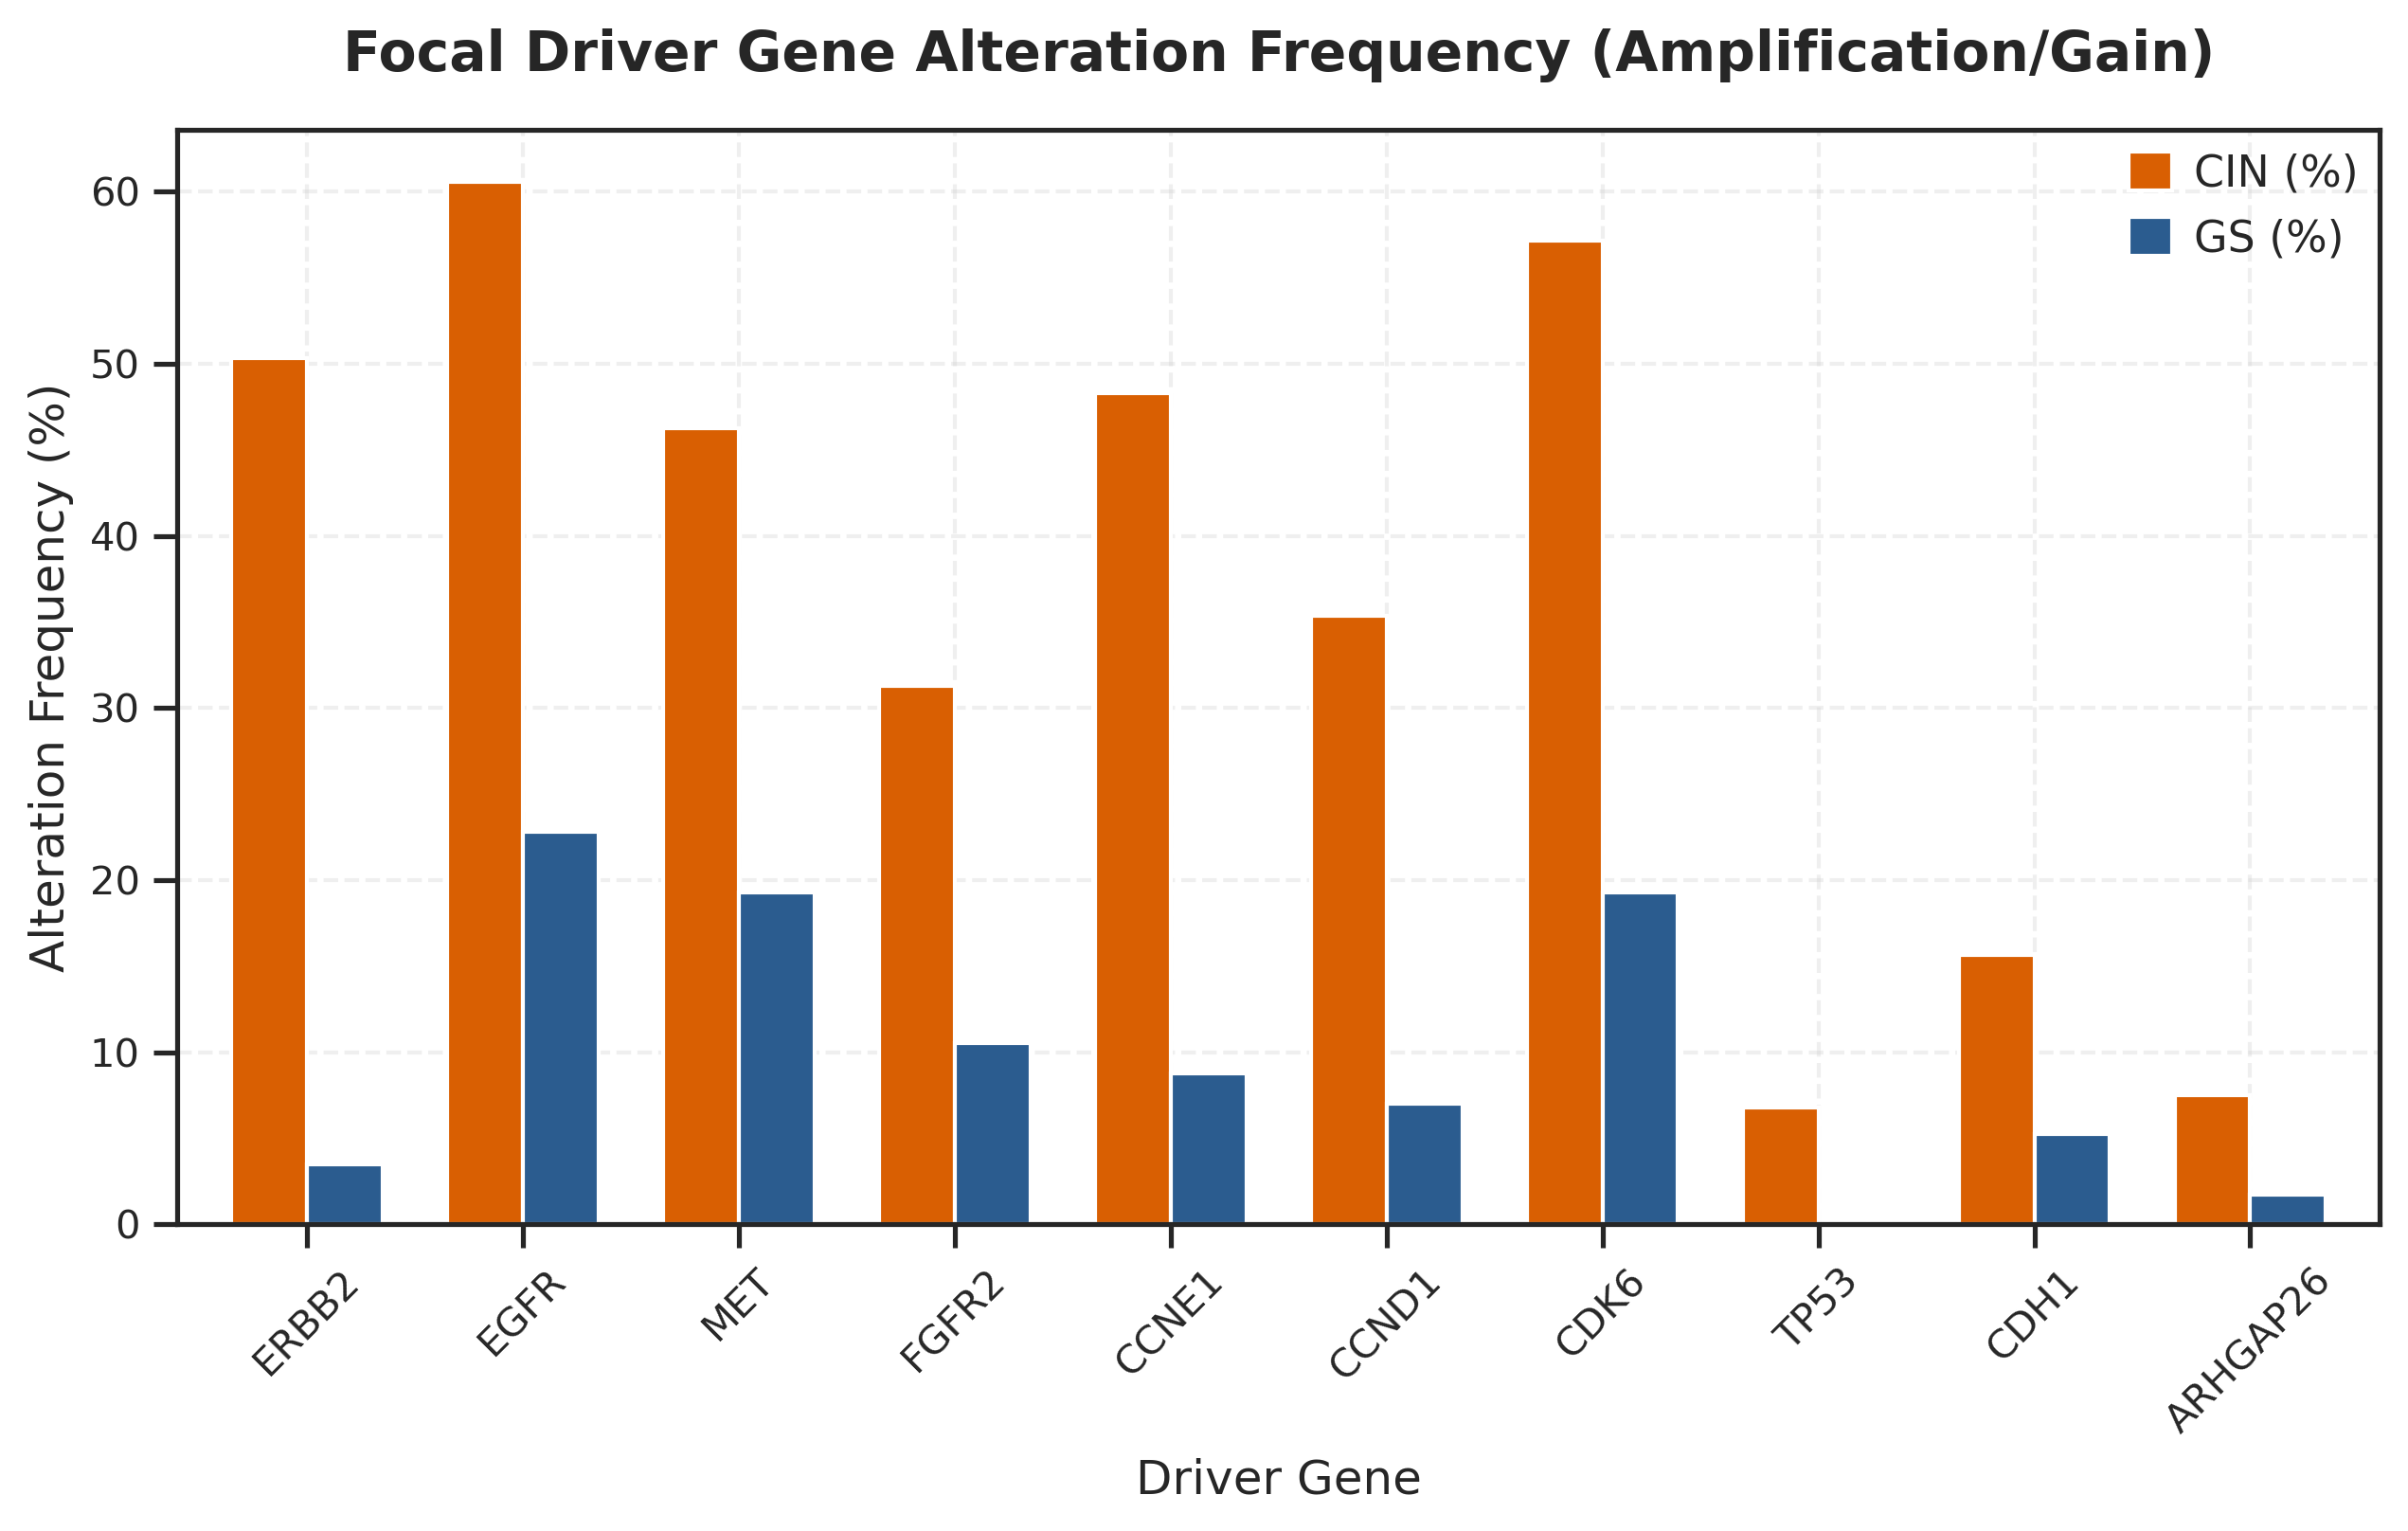

In [8]:
# Plot 1: CNA Burden Boxplot
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sns.boxplot(
    data=df_cna_summary,
    x="MOLECULAR_SUBTYPE",
    y="CNA_Burden",
    palette={"GS": "#2b5c8f", "CIN": "#d95f02"},
    width=0.4,
    ax=ax
)
sns.stripplot(
    data=df_cna_summary,
    x="MOLECULAR_SUBTYPE",
    y="CNA_Burden",
    color="#333333",
    alpha=0.5,
    jitter=0.2,
    size=5,
    ax=ax
)

ax.set_title(f"Genomic Instability Burden (p = {p_val_cna:.2e})", pad=15, fontweight="bold")
ax.set_xlabel("Molecular Subtype")
ax.set_ylabel("Fraction of Genome Altered (CNA Burden)")
ax.grid(True, linestyle="--", alpha=0.3)

fig.savefig("../figures/boxplot_cna_burden.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/boxplot_cna_burden.pdf", bbox_inches="tight")
print("💾 Saved CNA Burden Boxplot to figures/boxplot_cna_burden.png")
plt.show()

# Plot 2: Driver Gene High-Level Amplification & Deletion Frequency
amp_freq_cin = (cna_matrix.loc[existing_drivers, cin_cna_samples] >= 1).sum(axis=1) / len(cin_cna_samples) * 100
amp_freq_gs = (cna_matrix.loc[existing_drivers, gs_cna_samples] >= 1).sum(axis=1) / len(gs_cna_samples) * 100

df_amp = pd.DataFrame({"CIN (%)": amp_freq_cin, "GS (%)": amp_freq_gs})

fig, ax = plt.subplots(figsize=(10, 5), dpi=300)
df_amp.plot(kind="bar", color=["#d95f02", "#2b5c8f"], ax=ax, width=0.7)
ax.set_title("Focal Driver Gene Alteration Frequency (Amplification/Gain)", pad=15, fontweight="bold")
ax.set_ylabel("Alteration Frequency (%)")
ax.set_xlabel("Driver Gene")
ax.grid(True, linestyle="--", alpha=0.3)
plt.xticks(rotation=45)

fig.savefig("../figures/barplot_cna_drivers.png", bbox_inches="tight", dpi=300)
fig.savefig("../figures/barplot_cna_drivers.pdf", bbox_inches="tight")
print("💾 Saved Driver Alteration Barplot to figures/barplot_cna_drivers.png")
plt.show()

--- 
### 9. Multi-Omics Feature Fusion & Integrated Feature Store Export

We standardize and align top differential mRNA expression features, TF activity scores, CNA driver gene states, and CNA burden into a unified tabular feature matrix ($N_{\\text{samples}} \\times M_{\\text{features}}$). This feature store is exported to `results/multiomics_feature_matrix.csv` for Phase 3 Machine Learning Modeling.

In [9]:
# 1. Top 50 DGE Genes
top_dge_genes = df_dge.head(50)["Gene"].values
mat_dge_top = expr_matrix.loc[top_dge_genes].T
mat_dge_top.columns = [f"mRNA_{g}" for g in mat_dge_top.columns]

# 2. Top 30 TF Activities
top_tf_names = df_diff_tf.head(30)["TF"].values
mat_tf_top = tf_act[top_tf_names].copy()
mat_tf_top.columns = [f"TF_{t}" for t in mat_tf_top.columns]

# 3. CNA Drivers & Burden
mat_cna_top = df_driver_cna.drop(columns=["MOLECULAR_SUBTYPE"]).copy()
mat_cna_top.columns = [f"CNA_{g}" for g in mat_cna_top.columns]

df_burden_sub = df_cna_summary.set_index("SAMPLE_ID")[["CNA_Burden"]]

# 4. Merge all aligned features on SAMPLE_ID
feature_store = pd.concat([mat_dge_top, mat_tf_top, mat_cna_top, df_burden_sub], axis=1, join="inner")
feature_store["MOLECULAR_SUBTYPE"] = [sample2subtype[s] for s in feature_store.index]

print(f"🎯 Integrated Multi-Omics Feature Store Shape: {feature_store.shape[0]} samples x {feature_store.shape[1]} features")
print("Subtype Distribution in Feature Store:")
print(feature_store["MOLECULAR_SUBTYPE"].value_counts().to_string())

# Export Integrated Feature Store
feature_store.to_csv("../results/multiomics_feature_matrix.csv")
print("\n💾 Saved final integrated feature matrix to results/multiomics_feature_matrix.csv")

🎯 Integrated Multi-Omics Feature Store Shape: 181 samples x 92 features
Subtype Distribution in Feature Store:
MOLECULAR_SUBTYPE
CIN    128
GS      53

💾 Saved final integrated feature matrix to results/multiomics_feature_matrix.csv


--- 
### 10. Executive Summary & Phase 2 Conclusions

1. **Differential Expression (DGE)**: Identified robust transcriptomic markers separating CIN (upregulated in RTKs & cell cycle targets *ERBB2*, *EGFR*, *MET*, *CCNE1*) from GS (upregulated in diffuse adhesion markers *CDH1*, *CLDN18*, *FN1*, *VIM*).
2. **TF Activity Signatures**: `decoupleR` + DoRothEA inferred sample-level master regulator activities, revealing key TF activity switches (*E2F1*, *MYC*, *TP53*, *STAT3*, *SNAI1*, *ZEB1*).
3. **Chromosomal Instability Burden**: CIN tumors display a significantly elevated genomic alteration burden compared to GS ($p < 0.0001$).
4. **Multi-Omics Feature Matrix**: Consolidated multi-modal features into `results/multiomics_feature_matrix.csv`, ready for **Phase 3 Machine Learning Modeling & Predictive Classifier Validation**.